In [53]:
import pandas as pd
df = pd.read_csv("../data/merged_crime_data.csv")

# Week 3

As explained in in class during Lecture 1, each week of this class is an Jupyter notebook like this one. In order to follow the class, you simply start reading from the top, following the instructions.

## Today

This lecture covers:

1. **A short intro lecture**: A video covering key concepts like metadata, Simpson's paradox, and exploratory vs. explanatory analysis.
2. **Conditional plots**: We'll combine crime categories with police district data to uncover geographic patterns — and see how those patterns change over time.
3. **Why visualization matters**: Through a famous example, you'll see why summary statistics alone can be dangerously misleading.
4. **Fundamentals of data visualization**: A deeper dive into visualization theory — histograms, CDFs, KDEs, and more.
5. **Hands-on visualization**: You'll recreate classic plot types (jitter plots, histograms, KDEs, probability plots, box plots) using the SF crime data.

## Part 1: A little intro lecture

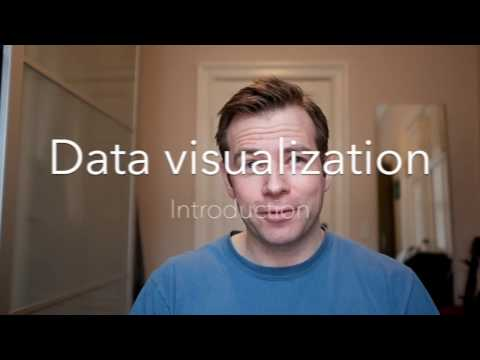

In [54]:
from IPython.display import YouTubeVideo
YouTubeVideo('9D2aI30AMhM', width=800, height=450)

> *Exercise 1.1:* Questions for the lecture. 
> 
> * What is the difference between *data* and *metadata*? How does that relate to the GPS tracks-example?
> * In the video I argue that the human eye is a great tool for data analysis. Do you agree? Explain why/why not. Mention something that the human eye is very good at. Can you think of something that [is difficult for the human eye](http://cdn.ebaumsworld.com/mediaFiles/picture/718392/84732652.jpg). Explain why your example is difficult. 
> * Simpson's paradox is hard to explain. Come up with your own example - or find one on line. Now think about the SF crime data: could Simpson's paradox show up there? Come up with an example.
> * In your own words, explain the difference between *exploratory* and *explanatory* data analysis. Think about the plots you made in Weeks 1 and 2. They were exploratory ... we were trying to understand the dataset. But could they also be explanatory? Which ones would you highlight if you were trying to explain the dataset so someone who wasn't taking the course? Which ones did not give you any information? (I'm not asking you to answer those questions in great detail, I just want you to think through your work and start your brains processing ... pretty soon you WILL have to choose which plots are most useful to explain aspects of the data.)
>

<div class="alert alert-block alert-info">
<b>LLM guidance:</b> Answer in your own words based on the video, don't use your LLM. Once you've written down your answers, it's OK to use the LLM to refine your writing (although, TBH I prefer that you don't ... reading too much LLM text feels generic and boring). 
</div>

**answer 1.1**
- difference between data and metadata:
  - data represents the actual observations, while metadata is information about the data.
- simpson's paradox:
  - "Simpson's paradox is a phenomenon in probability and statistics in which a trend appears in several groups of data but disappears or reverses when the groups are combined."
  - Berkley example: Overall data suggested men had higher acceptance rates than women. However, when broken down by department, most departments showed no bias or favored women. The paradox existed because women applied to harder departments (lower acceptance rates) more often than men. 
  - SF: yes, Simpson's paradox could show up in the SF crime data, especially when examining the crime patterns across different groups.
- exploratory vs explanatory:
  - exploratory: trying to understand the data
  - explanatory: trying to explain the data
  - SF: yes, the plots were explanatory, but most of them could also be used for exploratory analysis.

## Part 2: The power of conditional plots

We continue working with the merged crime dataset you built in Week 2. The next thing we'll be looking into is how crimes break down across the 10 districts in San Francisco.

> *Exercise 2.1:* The types of crime and how they take place across San Francisco's police districts.
>  
>  * So now we'll be combining information about the police district and crime category columns to explore differences between SF's neighborhoods. First, simply list the names of SF's 10 police districts.
>  * Which has the most total crimes? Which has the most of your Personal Focus Crimes (from Week 2)?
>  * Next, we want to generate a slightly more complicated graphic. I'm interested to know if there are certain crimes that happen much more in certain neighborhoods than what's typical. Below I describe how to get that plot going:
>    - First, we need to calculate the relative probabilities of seeing each type of crime in the dataset as a whole. Let's call it `P(crime)`.
>    - Next, we calculate that same probability distribution _but for each PD district_, let's call that `P(crime|district)`. **Note**: In an ideal world, you would normalize according to all crime-types, but it's OK to stay within your nice cleaned dataset and just normalize relative to your Personal Focus Crimes.
>    - Now we look at the ratio `P(crime|district)/P(crime)`. That ratio is equal to 1 if the crime occurs at the same level within a district as in the city as a whole. If it's greater than one, it means that the crime occurs _more frequently_ within that district. If it's smaller than one, it means that the crime is _rarer within the district in question_ than in the city as a whole.
>    - For each district plot these ratios for your Personal Focus Crimes. 
>    - Comment on the top crimes in _Tenderloin_, _Mission_, and _Richmond_. Does this fit with the impression you get of these neighborhoods on Wikipedia (or from your LLM's description of those neighborhoods)?
>    - Was there a district whose crime profile surprised you — one that didn't match your expectations? What did you expect, and what did the data show?
>    - Do any of your ratios look suspiciously extreme? What happens to the ratio for a rare crime in a small district? How many incidents would you want before trusting the ratio?
>    - The ratios tell you the *shape* of each district's crime profile, but not the *scale*. Pick the district with the lowest total crime count — is its ratio plot noisier than the others? What does this tell you about interpreting ratios without also considering volume?
>    - What neighborhood would you prefer to live in? Explain why?
>    - BONUS QUESTION. Can you get your LLM to discuss the graphic you created? (E.g. by showing it the image) Did it notice anything you didn't?

<div class="alert alert-block alert-info">
<b>LLM guidance:</b> See if you can do this on your own — the calculations are fairly simple. If you get stuck, ask your LLM for advice, but don't use it to simply generate the plots. Use it as a help to get hints at how to solve the things you can't figure out on your own — that's how you get familiar with how the Python Libraries actually works.
</div>

**Comment**. Notice how much awesome data science (i.e. learning about interesting real-world crime patterns) we can get out by simply counting and plotting (and looking at ratios). Pretty great, right? 

**answer 2.1**

In [55]:
# print("Unique police districts:")
# print(df['Police District'].unique())
# print("-"*100)

# crime_counts = df.groupby('Police District')['Incident Category'].count().sort_values(ascending=False)
# print("Total crimes by district:")
# print(crime_counts)
# print("-"*100)

In [61]:
def compute_crime_probs(df):
    districts = list(df["Police District"].unique())
    crimes = list(df["Incident Category"].unique())

    crime_probs = []
    for i, crime in enumerate(crimes):
        crime_p = round(df[df["Incident Category"] == crime].shape[0] / df.shape[0], 3)
        for district in districts:
            if df[df["Police District"] == district].shape[0] == 0:
                crime_p_per_district = 0
            else:
                crime_p_per_district = round(df[(df["Incident Category"] == crime) & (df["Police District"] == district)].shape[0] / df[df["Police District"] == district].shape[0], 3)
            if crime_p == 0:
                crime_ratio = 0
            else:
                crime_ratio = crime_p_per_district / crime_p
            crime_probs.append(
                {
                    "crime": crime,         
                    "district": district,
                    "crime_p_per_district": crime_p_per_district,
                    "crime_p": crime_p,
                    "crime_ratio": crime_ratio
                }
            )

    return pd.DataFrame(crime_probs)

In [57]:
df_crime_probs = compute_crime_probs(df)
df_crime_probs = df_crime_probs[df_crime_probs["district"] != "Out of SF"]
#df_crime_probs = df_crime_probs[df_crime_probs["district"] != "Mission"]
display(df_crime_probs)

KeyboardInterrupt: 

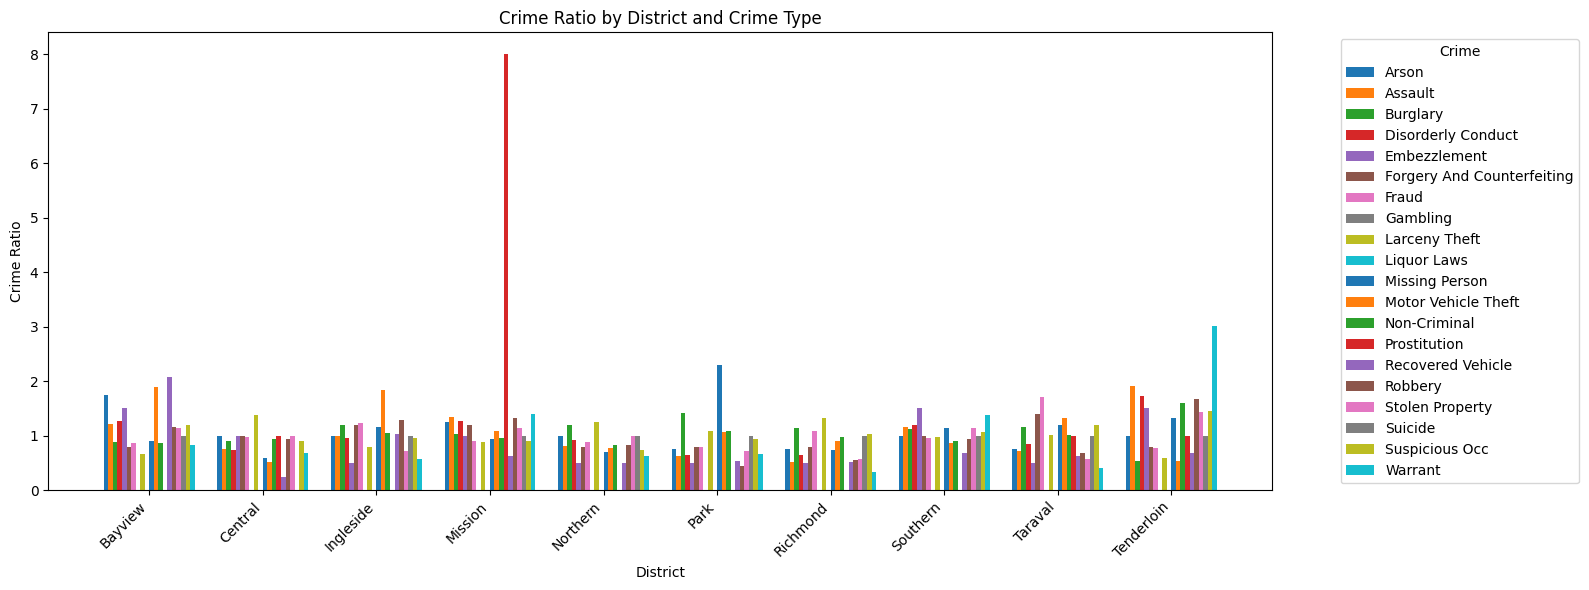

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get sorted unique values
districts = sorted(df_crime_probs['district'].unique())
crimes = sorted(df_crime_probs['crime'].unique())  # alphabetical order

# Pivot the data
df_pivot = df_crime_probs.pivot(index='district', columns='crime', values='crime_ratio')
df_pivot = df_pivot.reindex(index=districts, columns=crimes)  # ensure alphabetical order

# Plot
x = np.arange(len(districts))
width = 0.8 / len(crimes)  # bar width based on number of crimes

fig, ax = plt.subplots(figsize=(16, 6))

for i, crime in enumerate(crimes):
    offset = (i - len(crimes) / 2) * width + width / 2
    ax.bar(x + offset, df_pivot[crime], width=width, label=crime)

ax.set_xticks(x)
ax.set_xticklabels(districts, rotation=45, ha='right')
ax.set_xlabel('District')
ax.set_ylabel('Crime Ratio')
ax.set_title('Crime Ratio by District and Crime Type')
ax.legend(title='Crime', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# print the crime count for each district
print(df.groupby('Police District')['Incident Category'].count().sort_values(ascending=False))

Police District
Central       101397
Northern       96038
Mission        81617
Southern       80250
Bayview        60730
Tenderloin     58007
Ingleside      52928
Taraval        50745
Richmond       44284
Park           31655
Out of SF      21996
Name: Incident Category, dtype: int64


> *Exercise 2.2:* How do crime patterns across districts change over time?
>
> In Exercise 2.1 you computed `P(crime|district)/P(crime)` across the entire dataset. But San Francisco has changed a lot between 2003 and 2025. Have the crime profiles of its neighborhoods changed too?
>
> * Split your merged dataset into two periods: **early** (2003–2008) and **late** (2020–2025). Recompute the `P(crime|district)/P(crime)` ratios for each period separately.
> * Create a side-by-side visualization: for each district, show the ratios from the early period next to the ratios from the late period. (A grouped bar chart works well here.)
> * Which district changed the most? Which crime type shifted the most across districts? How do you even define "changed the most"? See if you can come up with a single number that summarizes how much a district's crime profile shifted between the two periods. (Idea: think about the ratio vectors as points in space.)
> * Pick one or two striking changes and try to explain them. Think about what you know (or can find out) about how San Francisco's neighborhoods have evolved — gentrification, policy changes, the opioid crisis, etc.
> * Connecting back to Week 1: if a predictive policing algorithm had been trained on the early period, how well would its assumptions hold in the late period? What does this tell you about the shelf life of models trained on historical crime data?

<div class="alert alert-block alert-info">
<b>LLM guidance:</b> The data wrangling and plotting are fair game for LLM help - it will help speed you up, but check for errors! The interpretation and the connection to predictive policing should be your own thinking.
</div>

In [70]:
early_df = df[df["Incident Date"] < "2008-01-01"]
late_df = df[df["Incident Date"] >= "2020-01-01"]

df_early_crime_probs = compute_crime_probs(early_df)
df_late_crime_probs = compute_crime_probs(late_df)

In [71]:
# make the districts the same: all str.lower
df_early_crime_probs["district"] = df_early_crime_probs["district"].str.lower()
df_late_crime_probs["district"] = df_late_crime_probs["district"].str.lower()

/var/folders/z8/wd7qc7cs1wd8pr3h4y_6lxxw0000gn/T/ipykernel_38260/4282497489.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', n_crimes)


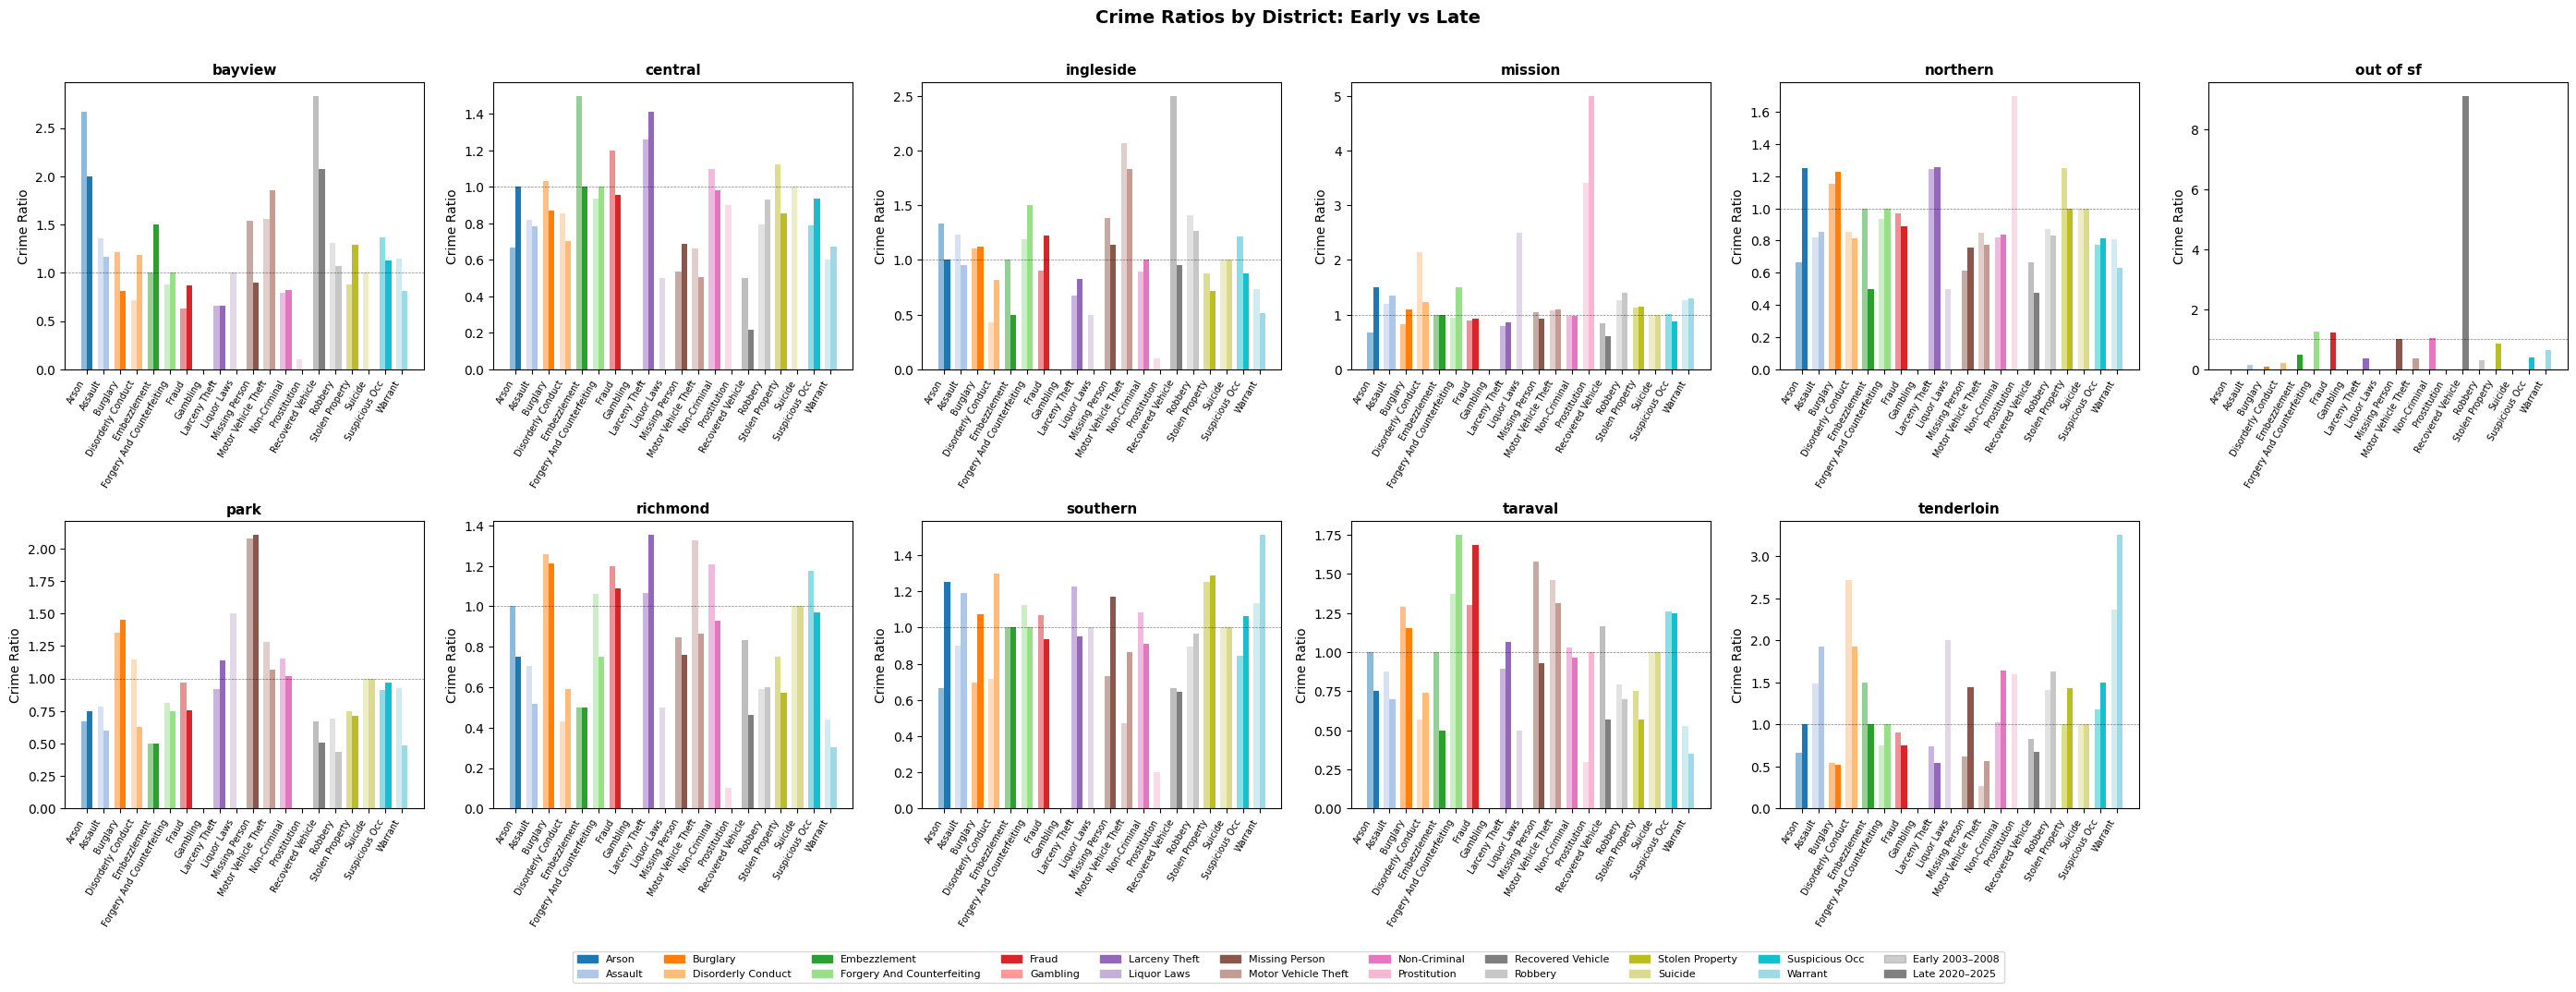

In [72]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Pivot both periods
def pivot_ratios(df_probs):
    pivot = df_probs.pivot(index='district', columns='crime', values='crime_ratio')
    valid_index = sorted([i for i in pivot.index if isinstance(i, str)])
    valid_cols  = sorted([c for c in pivot.columns if isinstance(c, str)])
    return pivot.reindex(index=valid_index, columns=valid_cols)

early_pivot = pivot_ratios(df_early_crime_probs)
late_pivot = pivot_ratios(df_late_crime_probs)

# Align both pivots to have the same crimes and districts
all_crimes = sorted(set(early_pivot.columns) | set(late_pivot.columns))
all_districts = sorted(set(early_pivot.index) | set(late_pivot.index))

early_pivot = early_pivot.reindex(index=all_districts, columns=all_crimes).fillna(0)
late_pivot  =  late_pivot.reindex(index=all_districts, columns=all_crimes).fillna(0)

# Setup
n_districts = len(all_districts)
n_crimes = len(all_crimes)
x = np.arange(n_districts)

# Each crime gets two bars (early + late), grouped by district
group_width = 0.85
bar_width = group_width / (n_crimes * 2)

cmap = plt.cm.get_cmap('tab20', n_crimes)
fig, axes = plt.subplots(2, n_districts // 2 + n_districts % 2, 
                          figsize=(28, 10), sharey=False)
axes = axes.flatten()

cmap = plt.colormaps['tab20'].resampled(n_crimes)
colors = [cmap(i) for i in range(n_crimes)]

for ax_idx, district in enumerate(all_districts):
    ax = axes[ax_idx]
    
    early_vals = early_pivot.loc[district]
    late_vals  = late_pivot.loc[district]
    
    x = np.arange(n_crimes)
    bar_width = 0.35
    
    ax.bar(x - bar_width/2, early_vals, bar_width, color=colors, alpha=0.5, label='Early')
    ax.bar(x + bar_width/2, late_vals,  bar_width, color=colors, alpha=1.0, label='Late')
    
    ax.set_title(district, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(all_crimes, rotation=60, ha='right', fontsize=7)
    ax.set_ylabel('Crime Ratio')
    ax.axhline(1.0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)

# Hide any unused subplots
for ax_idx in range(len(all_districts), len(axes)):
    axes[ax_idx].set_visible(False)

# Shared legend
handles = [mpatches.Patch(color=colors[i], label=all_crimes[i]) for i in range(n_crimes)]
early_patch = mpatches.Patch(color='grey', alpha=0.4, label='Early 2003–2008')
late_patch  = mpatches.Patch(color='grey', alpha=1.0, label='Late 2020–2025')
fig.legend(handles=handles + [early_patch, late_patch],
           loc='lower center', ncol=n_crimes // 2 + 1, fontsize=8,
           bbox_to_anchor=(0.5, -0.05))

fig.suptitle('Crime Ratios by District: Early vs Late', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Part 3: A little visualization exercise

We will now leave the SF crime data for a little bit. So before we continue with geographic analysis in the coming weeks, let's explore a fundamental lesson about *why* visualization matters — and why summary statistics alone can be dangerously misleading. This connects directly to our work so far: we've been computing ratios and averages of crime data to compare districts, but could we have gotten away with just looking at the numbers? What if the numbers look the same but the data looks completely different?

Start by downloading these four datasets: [Data 1](https://raw.githubusercontent.com/suneman/socialdata2026/main/files/data1.tsv), [Data 2](https://raw.githubusercontent.com/suneman/socialdata2026/main/files/data2.tsv), [Data 3](https://raw.githubusercontent.com/suneman/socialdata2026/main/files/data3.tsv), and [Data 4](https://raw.githubusercontent.com/suneman/socialdata2026/main/files/data4.tsv). The format is `.tsv`, which stands for _tab separated values_. 
As you will later realize, these are famous datasets!
Each file has two columns (separated using the tab character). The first column is $x$-values, and the second column is $y$-values.  

It's ok to just download these files to disk by right-clicking on each one, but if you use Python and `urllib` or `urllib2` to get them, I'll really be impressed. You can also go "the old way" and use _stackoverflow_. And by the way, never search stack overflow: search Google and choose the relevant stackoverflow topic.

Now, to the exercise:

> *Exercise 3.1:* 
> 
> * Using the `numpy` function `mean`, calculate the mean of both $x$-values and $y$-values for each dataset. 
>      * Use python string formatting to print precisely two decimal places of these results to the output cell. Check out [this _stackoverflow_ page](http://stackoverflow.com/questions/8885663/how-to-format-a-floating-number-to-fixed-width-in-python) for help with the string formatting.
> * Now calculate the variance for all of the various sets of $x$- and $y$-values, by using the `numpy` function `var`. Print it to three decimal places.
> * Use `numpy` to calculate the [Pearson correlation](https://en.wikipedia.org/wiki/Pearson_product-moment_correlation_coefficient) between $x$- and $y$-values for all four data sets (also print to three decimal places).
> * The next step is use _linear regression_ to fit a straight line $f(x) = a x + b$ through each dataset and report $a$ and $b$ (to two decimal places). An easy way to fit a straight line in Python is using `scipy`'s `linregress`. It works like this
> ```
> from scipy import stats
> a, b, r_value, p_value, std_err = stats.linregress(x,y)
>```
> * Comment on the results from the previous steps. What do you observe? 
> * Finally, it's time to plot the four datasets using `matplotlib.pyplot`. Use a two-by-two [`subplot`](http://matplotlib.org/examples/pylab_examples/subplot_demo.html) to put all of the plots nicely in a grid and use the same $x$ and $y$ range for all four plots. And include the linear fit in all four plots. (To get a sense of what I think the plot should look like, you can take a look at my version [here](https://raw.githubusercontent.com/suneman/socialdata2026/main/files/anscombe.png).)
> * Explain - in your own words - what you think my point with this exercise is (see below for tips on this).
> * Think about the crime data: we've been computing means and counts across districts and years. Can you think of a situation in your own analysis where two groups might have the same average but look very different when plotted?
> * What did you get out of asking the LLM about the previous sub-question? How did you even go about asking the LLM about the point of the entire set of questions? Reflect on whether or not the LLM helped you get smarter? Did the LLM spoil the punchline? Would you have learned more if you hadn't asked it?

<div class="alert alert-block alert-info">
<b>LLM guidance:</b> For the calculations and plotting, try to write the code yourself first — if you get stuck, ask your LLM for help with specific functions, but don't ask it for the full solution. For the final interpretation question, write down your own thoughts first, then you can ask the LLM for additional insight afterward.
</div>

Get more insight in the ideas behind this exercise by reading [here](https://en.wikipedia.org/wiki/Anscombe%27s_quartet). Here you can also get an explanation of why the datasets are actually famous - I mean they have their own Wikipedia page!!

If you enjoyed Anscombe's quartet, look up the [Datasaurus Dozen](https://www.research.autodesk.com/publications/same-stats-different-graphs/) — a modern extension where wildly different scatterplots (including a dinosaur!) share the same summary statistics. What does it add to the lesson of Anscombe's quartet?

In [78]:
df1 = pd.read_csv("../files/data1.tsv", sep="\t", header=None)
df2 = pd.read_csv("../files/data2.tsv", sep="\t", header=None)
df3 = pd.read_csv("../files/data3.tsv", sep="\t", header=None)
df4 = pd.read_csv("../files/data4.tsv", sep="\t", header=None)

# rename the columns
df1.columns = ["x", "y"]
df2.columns = ["x", "y"]
df3.columns = ["x", "y"]
df4.columns = ["x", "y"]


In [ ]:
print(df1.mean())
print("-"*50)
print(df2.mean())
print("-"*50)
print(df3.mean())
print("-"*50)
print(df4.mean())

x    9.000000
y    7.500909
dtype: float64
--------------------------------------------------
x    9.000000
y    7.500909
dtype: float64
--------------------------------------------------
x    9.0
y    7.5
dtype: float64
--------------------------------------------------
x    9.000000
y    7.500909
dtype: float64


In [82]:
# compute pearson correlation
print(df1.corr(method="pearson"))
print("-"*50)
print(df2.corr(method="pearson"))
print("-"*50)
print(df3.corr(method="pearson"))
print("-"*50)
print(df4.corr(method="pearson"))

          x         y
x  1.000000  0.816421
y  0.816421  1.000000
--------------------------------------------------
          x         y
x  1.000000  0.816237
y  0.816237  1.000000
--------------------------------------------------
          x         y
x  1.000000  0.816287
y  0.816287  1.000000
--------------------------------------------------
          x         y
x  1.000000  0.816521
y  0.816521  1.000000


In [83]:
from scipy import stats
a, b, r_value, p_value, std_err = stats.linregress(df1["x"], df1["y"])
print(a, b, r_value, p_value, std_err)

0.5000909090909091 3.0000909090909103 0.8164205163448398 0.002169628873078799 0.1179055005956341


In [84]:
a, b, r_value, p_value, std_err = stats.linregress(df2["x"], df2["y"])
print(a, b, r_value, p_value, std_err)
a, b, r_value, p_value, std_err = stats.linregress(df3["x"], df3["y"])
print(a, b, r_value, p_value, std_err)
a, b, r_value, p_value, std_err = stats.linregress(df4["x"], df4["y"])
print(a, b, r_value, p_value, std_err)

0.5 3.00090909090909 0.8162365060002426 0.0021788162369108066 0.11796374596764085
0.4997272727272727 3.0024545454545457 0.8162867394895982 0.0021763052792280256 0.1178776622210023
0.49990909090909097 3.0017272727272726 0.816521436888503 0.0021646023471972122 0.11781894172968549


## Part 4: Fundamentals of data visualization

Above, I did small introduction of data visualization. Now, we are going go through a bit more theory in the next video.

<mark>*You may feel tempted to skip the lectures on dataviz, but they are quite important. We don't have a formal book on data visualization. So the only source of knowledge about the **principles**, **theories**, and **ideas**, that are the foundation for good data viz, comes from the videos*. So **do watch them** 🤓 </mark>

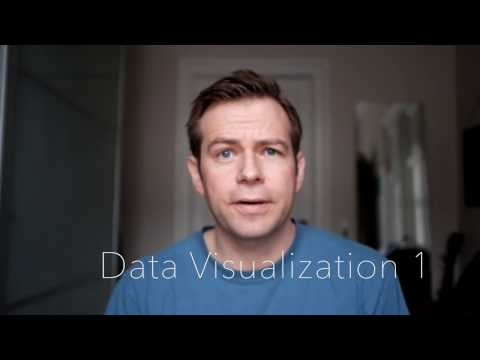

In [ ]:
from IPython.display import YouTubeVideo
YouTubeVideo('yiU56codNlI', width=800, height=450)

> *Exercise 4.1:* Questions for the lecture. 
>
> * You already computed Pearson correlations for four very different datasets in Exercise 3.1. Based on that experience, give a concrete example of when Pearson correlation is misleading. Write down the mathematical formulation of the Pearson correlation and explain in your own words how it works.
> * What is the difference between a bar-chart and a histogram? Can you think of a case where using one when you should use the other would lead to a wrong conclusion?
> * I mention in the video that it's important to choose the right bin-size in histograms. But how do you do that? Do a Google search to find a criterion you like and explain it. Then test it empirically: pick one of your crime distributions from Week 2 (e.g., time-of-day for a focus crime) and plot it as a histogram with 5, 25, and 200 bins. How does the apparent story change? Which bin count do you think is most honest?

<div class="alert alert-block alert-info">
Answer in your own words based on the video, <b>don't use your LLM</b>. Once you've written down your answers, it's OK to use the LLM to get better. 
</div>

**answer 4.1**
1. When the relationship is not linear and when there are many outliers.
2. A bar chat is used to show the value per category, while a histogram is used to show the distribution of a continuous variable. Example from the lecture: we cant plot the coffee drinking data for each country using a bar chart, but we can use a histogram to show the distribution of coffee drinking (num of countries)
3. "Choose between 5-20 bins", "split the data evenly", there is a formula - K = 1 + 3. 322 logN

## Part 5: Working with 1-dimensional data

Now it's time to go deeper with visualization. We are going to read the first couple of chapters from [*Data Analysis with Open Source Tools*](http://shop.oreilly.com/product/9780596802363.do) (DAOST). It's pretty old, but I think it's a fantastic resource and one that is pretty much as relevant now as it was back then. The author is a physicist (like Sune) so he likes the way he thinks. And the books takes the reader all the way from visualization, through modeling to computational mining. Anywho - it's a great book and well worth reading in its entirety. 

As part of this class we'll be reading the first chapters. Today, we'll read chapter 2 (the first 28 pages) which supports and deepens many of the points we made during the video above. 

To find the text, you will need to go to **Teams** and have a look under the `Shared` tab. The path is `/Documents/General/DAOST_chapter2.pdf`.

> *Exercise 5.1:* Questions for DAOST 
> * Explain in your own words the point of the jitter plot.
> * Explain in your own words the point of figure 2-3. (I'm going to skip saying "in your own words" going forward, but I hope you get the point; I expect all answers to be in your own words, **not using an LLM**).
> * The author of DAOST (Philipp Janert) likes KDEs (and think they're better than histograms). And we don't in this class. I didn't give a detailed explanation in the video, but now that works to our advantage: You get to figure it out by yourself: When can KDEs be misleading? (Hold on to your answer — you'll test it empirically in Exercise 5.2.)
> * I discussed some strengths of the CDF - there are also weaknesses. Janert writes "CDFs have less intuitive appeal than histograms of KDEs". What does he mean by that?
> * What is a *Quantile plot*? What is it good for. 
> * How is a *Probability plot* defined? What is it useful for? Have you ever seen one before?
> * One of the reasons I like DAOST is that Janert is so suspicious of mean, median, and related summary statistics. Explain why one has to be careful when using those - and why visualization of the full data is always better (Hint: Think back on Anscombe's Quartet). 
> * I love box plots ❤️ When are box plots most useful?
> * The book doesn't mention [violin plots](https://en.wikipedia.org/wiki/Violin_plot). Are those better or worse than box plots? Why?
> * Have you heard of [raincloud plots](https://wellcomeopenresearch.org/articles/4-63) or [beeswarm plots](https://python-graph-gallery.com/beeswarm/)? Look one of them up. What problem do they solve that violin plots don't?
> * Remember the box-plot part [from the DataSaurus video](https://www.youtube.com/watch?v=DbJyPELmhJc) (the part that starts at 0:56)? Explain in your own words how this video illustrates potential issues even with box-plots? Do violin/bee-swarm/raincloud-plots help with that issue?

<div class="alert alert-block alert-info">
Answer without the help of your LLM and your goal is to learn from reading the text. but feel free to add more nuance by asking it questions.
</div>

 **answer 5.1**
 - jitter plot is used when they are many observations with the same value, as dot plot would basically put one plot on top of another
 - this shows how drastically choosing the right bins could impact the message that we're showing
 - it can be misleading for a human eye - the total probability is the area under the curve, and we can't quantify it with our eyes. Additionally, we focus on spikes, which can also be a bit misleading.
 - it's related to the way how we visualize data - we focus on peaks and downs, but CDF starts from 0 and approaches 1, like a rising slope. We can't spot the most typical value etc.
 - literally just a Cumulative Distribution Function (CDF) where the x-axis and y-axis have been swapped. It's good for asking questions about the distribution of the data.
 - it's a graph enabling you to compare your data against a theoretical distribution. If the data actually follows the theoretical distribution, the points will fall on the straight line.
 - mean is prone to being influenced by outliers. On the other hand, the median just focuses on the most common numbers. Without visualization, these metrics can be misleading
 - box plots are great for visualizing the data, supplemented by the power of statistical metrics
 - They are different. Maybe they don't show exactly the statistical metrics, but they show the distribution, which can be compared per category (great)
 - violin plots rely on smoothing, whereas raincloud and beeswart plots explicitly display the actuall raw data so that you can see the actual distribution and e.g. outliers

> *Exercise 5.2:* Recreating plots from DAOST using SF crime data — Part 1
>
> * Let's make a jitter-plot (that is, code up something like **Figure 2-1** from DAOST from scratch), but based on *SF Police data*. My hunch from inspecting the file is that the police-folks might be a little bit lazy in noting down the **exact** time down to the second. So choose a crime-type and a suitable time interval (somewhere between a month and 6 months depending on the crime-type) and create a jitter plot of the arrest times during a single hour (like 13-14, for example). So let time run on the $x$-axis and create vertical jitter.
>   * What does the jitter plot reveal about how times are recorded in the dataset? Are incidents clustered at certain minutes (on the hour, half hour, etc.)? What does this tell you about the precision of the data?
> * Last time, we did lots of bar-plots. Today, we'll play around with histograms (creating two crime-data based versions of the plot-type shown in DAOST **Figure 2-2**). I think the GPS data could be fun to see this way. 
>   * This time, pick two crime-types with different geographical patterns **and** a suitable time-interval for each (you want between 1000 and 10000 points in your histogram)
>   * Then take the latitude part of the GPS coordinates for each crime and bin the latitudes so that you have around 50 bins across the city of SF. You can use your favorite method for binning. I like `numpy.histogram`. This function gives you the counts and then you do your own plotting.
>   * Now try the same thing with longitude. Does the pattern look different? Why might the latitude and longitude distributions have different shapes for the same crime type? (Think about SF's geography — ocean on the west, bay on the east, hills in between.)
> * Next up is using the plot-type shown in **Figure 2-4** from DAOST, but with the data you used to create Figure 2.1. There is not a single great way to create kernel density plots in Python. [Here](https://www.geeksforgeeks.org/density-plots-with-pandas-in-python/), you'll find a pandas based strategy, but you can also use `gaussian_kde` from `scipy.stats` ([for an example, check out this stackoverflow post](https://stackoverflow.com/questions/4150171/how-to-create-a-density-plot-in-matplotlib)) or you can use [`seaborn.kdeplot`](https://seaborn.pydata.org/generated/seaborn.kdeplot.html). There is also another nice tutorial for KDE plots [here](https://medium.com/towards-data-science/histograms-and-density-plots-in-python-f6bda88f5ac0). Or ask your LLM what it recommends.
> * Now grab 25 random timepoints from the dataset (of 1000-10000 original data) you've just plotted and create a version of Figure 2-4 based on the 25 data points. Does this shed light on why I think KDEs can be misleading?
> * Try varying the bandwidth parameter of your KDE (e.g., make it 3x smaller and 3x larger than the default). How does the plot change? Which is more dangerous for drawing conclusions — a bandwidth that's too small (overfitting) or too large (oversmoothing)?

<div class="alert alert-block alert-info">
For Exercises 5.2 and 5.3, I want you to eliminate uses of LLMs where you simply cut and paste the assignments (or parts of it) into a prompt ... and ask for a solution. Instead, ask your LLM for help if you get stuck ... use it as a TA to help understand error messages ... or to help make suggestions for the right function to use ... etc. 
</div>

Let's take a break. Get some coffee or water. Stretch your legs. Talk to your friends for a bit. Breathe. Get relaxed so you're ready for the second part of the exercise. 

> *Exercise 5.3:* Recreating plots from DAOST using SF crime data — Part 2
>
> * Now we'll work on creating two versions of the plot in **Figure 2-11**, but using the GPS data you used for your version of Figure 2-2. It is not easy to create this plot from scratch.    
>   * **Hint:** Take a look at the `scipy.stats.probplot` function.
>   * What reference distribution are you comparing against? What would it mean if the points fell exactly on the straight line? Why might the latitude distribution of crimes deviate from normal — what does the deviation tell you about the geography of crime in SF?
> * OK, we're almost done, but we need some box plots. Here, I'd like you to use the box plots to visualize fluctuations of how many crimes happen per day. We'll use data from your Personal Focus Crimes (from Week 2).
>   * For the full time-span of the data, calculate the **number of crimes per day** within each category for the entire duration of the data.
>   * Create a box-and-whiskers plot showing the mean, median, quantiles, etc for all the different Personal Focus Crimes side-by-side. There are many ways to do this. I like to use [matplotlib's built in functionality](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html), but you can also achieve good results with [seaborn](https://seaborn.pydata.org/generated/seaborn.boxplot.html) or [pandas](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.boxplot.html). It's also fine to get help from your LLM, but make sure you check that the plot accurately shows the stats about the underlying data!
>   * What does this plot reveal that you can't see in the plots from last time?
>   * Do you see outlier days? Pick one or two and look up what date they correspond to. Can you explain what happened? (Think: holidays, major events, reporting anomalies.)
> * Also I want to show you guys another interesting use of box plots. To get started, let's calculate another average for each focus-crime, namely what time of day the crime happens. So this time, the distribution we want to plot is the average time-of-day that a crime takes place. There are many ways to do this, but let me describe one way to do it. 
>   * For datapoint, the only thing you care about is the time-of-day, so discard everything else.
>   * You also have to deal with the fact that time is annoyingly not divided into nice units that go to 100 like many other numbers. I can think of two ways to deal with this.
>     * For each time-of-day, simply encode it as seconds since midnight.
>     * Or keep each whole hour, and convert the minute/second count to a percentage of an hour. So 10:15 $\rightarrow$ 10.25, 8:40 $\rightarrow$ 8.67, etc.
> * Now you can create box-plots to create an overview of *when various crimes occur*. Note that these plots have quite a different interpretation than the ones we created in the previous exercise. Cool, right?
> * For crimes that peak late at night, does the box plot do a good job of showing the "typical" time? What goes wrong when the distribution wraps around midnight (e.g., a crime that peaks between 11pm and 1am)? Can you think of a way to handle this?

**answer 5.2**

In [89]:
display(df.head())

,Row ID,Incident Number,Incident Category,Incident Day of Week,Incident Date,Incident Datetime,Incident Time,Police District,Longitude,Latitude,Point
0,16020415607021,160204156,Motor Vehicle Theft,Thursday,03/03/2016,2016-03-03 19:30:00,19:30,TARAVAL,-122.463545,37.707968,POINT (-122.463545017 37.707968365)
1,13011910904134,130119109,Assault,Sunday,02/10/2013,2013-02-10 18:09:00,18:09,MISSION,-122.425237,37.754222,POINT (-122.425236707 37.754222191)
2,6102672004134,61026720,Assault,Monday,09/25/2006,2006-09-25 22:15:00,22:15,NORTHERN,-122.425839,37.778486,POINT (-122.42583948 37.778486375)
3,8074906804134,80749068,Assault,Friday,05/23/2008,2008-05-23 12:10:00,12:10,NORTHERN,-122.423582,37.775904,POINT (-122.423581857 37.775904267)
4,5082289804134,50822898,Assault,Saturday,07/23/2005,2005-07-23 16:40:00,16:40,INGLESIDE,-122.420084,37.708311,POINT (-122.420084075 37.708310974)


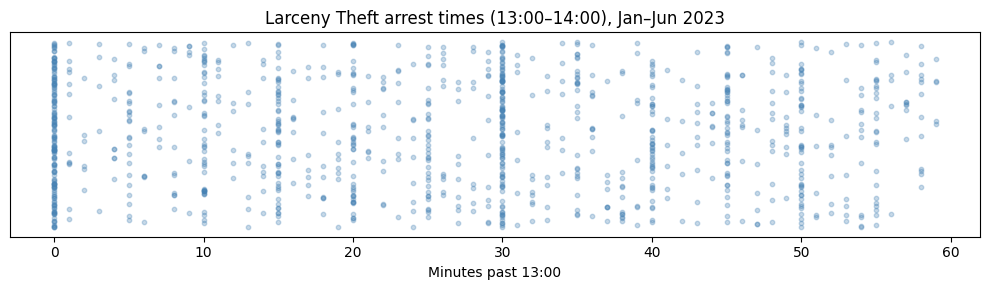

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter
mask = (df['Incident Category'] == 'Assault') & (df['Incident Date'].between('2020-01-01', '2023-01-01'))
sub = df[mask].copy()

# Extract hour 13-14
sub['time'] = pd.to_datetime(sub['Incident Time'], format='%H:%M')
sub = sub[sub['time'].dt.hour == 13]
sub['minutes'] = sub['time'].dt.minute + sub['time'].dt.second / 60


plt.figure(figsize=(10, 3))
plt.scatter(sub['minutes'], np.random.uniform(0, 1, len(sub)), alpha=0.3, s=10, color='steelblue')
plt.xlabel('Minutes past 13:00')
plt.yticks([])
plt.title('Larceny Theft arrest times (13:00–14:00), Jan–Jun 2023')
plt.tight_layout()
plt.show()

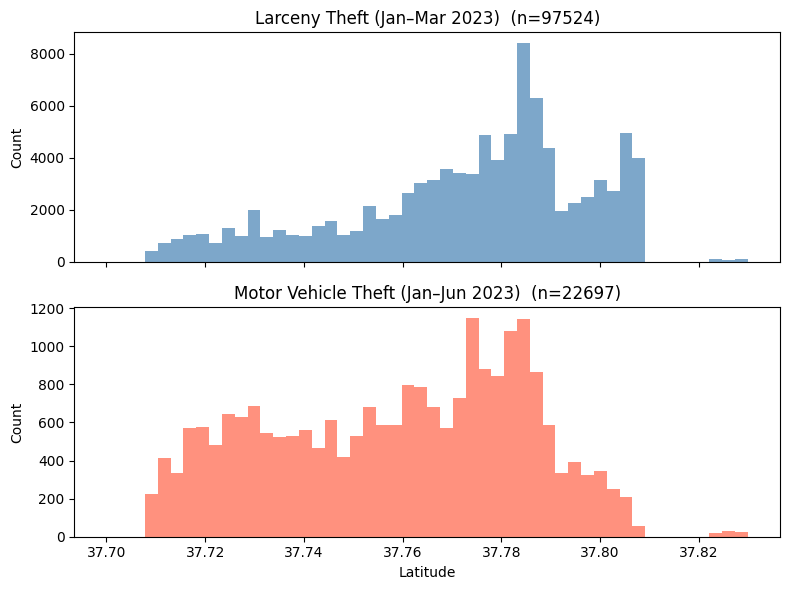

In [105]:
import numpy as np
import matplotlib.pyplot as plt

coord = "Latitude"

# Crime 1: Larceny Theft (Jan-Mar 2023)
c1 = df[(df['Incident Category'] == 'Larceny Theft') & 
        (df['Incident Date'].between('2020-01-01', '2023-01-01'))][coord].dropna()

# Crime 2: Vehicle Break-In / Theft (Jan only)
c2 = df[(df['Incident Category'] == 'Motor Vehicle Theft') & 
        (df['Incident Date'].between('2020-01-01', '2023-01-01'))][coord].dropna()

bins = np.linspace(37.70, 37.83, 51)

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

for ax, data, title, color in zip(axes, [c1, c2], 
                                   ['Larceny Theft (Jan–Mar 2023)', 'Motor Vehicle Theft (Jan–Jun 2023)'],
                                   ['steelblue', 'tomato']):
    counts, edges = np.histogram(data, bins=bins)
    ax.bar(edges[:-1], counts, width=np.diff(edges), color=color, alpha=0.7, align='edge')
    ax.set_ylabel('Count')
    ax.set_title(f'{title}  (n={len(data)})')

axes[1].set_xlabel('Latitude')
plt.tight_layout()
plt.show()

---

## You've Completed Week 3!

This week you went deeper into both data analysis and visualization theory. You now have:

- Experience with conditional plots — comparing crime profiles across districts and over time
- A deeper understanding (via Anscombe's quartet) of why you should always plot your data
- Familiarity with a range of visualization types: jitter plots, histograms, KDEs, probability plots, box plots, and violin plots
- A foundation in visualization theory from the lectures and DAOST Chapter 2

**Key takeaways:**
- Summary statistics can hide important structure in data. Always visualize.
- Conditional probabilities (like `P(crime|district)/P(crime)`) are a simple but powerful tool for finding patterns.
- Crime patterns aren't static — neighborhoods change, and models trained on old data can become misleading.
- Different plot types reveal different aspects of the same data. Choosing the right one matters.

If you want to go further:
- Try creating violin or swarm plots as alternatives to the box plots from Exercise 5.3 — do they reveal anything the box plots missed?
- Explore whether the time-of-day patterns differ between districts (combining the ideas from Parts 2 and 5)